In [2]:
import numpy as np
import pandas as pd


In [3]:
df=pd.read_csv("titanic_toy.csv")

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.shape

(891, 4)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [7]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [8]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [10]:
x=df.drop(columns=["Survived"])
y=df[["Survived"]]

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [14]:
x_train.head()

,Age,Fare,Family
331,45.5,28.5000,0
733,23.0,13.0000,0
382,32.0,7.9250,0
704,26.0,7.8542,1
813,6.0,31.2750,6


In [15]:
x_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [16]:
x_train["Age"].skew()

np.float64(0.3310017370749743)

In [18]:
import scipy.stats as stats
import matplotlib.pyplot as plt

In [35]:
# fig,ax=plt.subplots(1,2,figsize=(12,6))

# stats.probplot(x_train["Age"],dist="norm",plot=ax[0])
# ax[0].set_title("before distribution")

In [36]:
#USING SKLEARN

In [37]:
from sklearn.compose import ColumnTransformer

In [38]:
x_train.head()

,Age,Fare,Family
331,45.5,28.5000,0
733,23.0,13.0000,0
382,32.0,7.9250,0
704,26.0,7.8542,1
813,6.0,31.2750,6


In [39]:
trf=ColumnTransformer([
    ("age_imputer",SimpleImputer(strategy="mean"),["Age"]),
    ("imputer_fare",SimpleImputer(strategy="median"),["Fare"])
],remainder="passthrough")

In [41]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.fit_transform(x_test)

In [ ]:
x_train_transformed

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.4   ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))

In [45]:
x_train_df=pd.DataFrame(x_train_transformed,columns=trf.get_feature_names_out(),index=x_train.index)

In [46]:
x_train_df.head()

,age_imputer__Age,imputer_fare__Fare,remainder__Family
331,45.5,28.5000,0.0
733,23.0,13.0000,0.0
382,32.0,7.9250,0.0
704,26.0,7.8542,1.0
813,6.0,31.2750,6.0


In [47]:
x_train_df.isnull().mean()

age_imputer__Age      0.0
imputer_fare__Fare    0.0
remainder__Family     0.0
dtype: float64

In [48]:
# same for test
x_test_df=pd.DataFrame(x_test_transformed,columns=trf.get_feature_names_out(),index=x_test.index)

In [49]:
x_test_df.head()

,age_imputer__Age,imputer_fare__Fare,remainder__Family
709,30.505845,15.2458,2.0
439,31.000000,10.5000,0.0
840,20.000000,7.9250,0.0
720,6.000000,33.0000,1.0
39,14.000000,11.2417,1.0


In [51]:
x_test_df.isnull().sum()

age_imputer__Age      0
imputer_fare__Fare    0
remainder__Family     0
dtype: int64

In [52]:
from sklearn.pipeline import Pipeline

In [61]:
x_train.head(2)

,Age,Fare,Family
331,45.5,28.5,0
733,23.0,13.0,0


In [87]:
trf=ColumnTransformer([
    ("age_mean",SimpleImputer(strategy="mean"),["Age"]),
    ("age_median",SimpleImputer(strategy="median"),["Age"])
], remainder="passthrough")

In [88]:
x_train_trf=trf.fit_transform(x_train)

In [89]:
x_train_trf_df=pd.DataFrame(x_train_trf,columns=trf.get_feature_names_out(),index=x_train.index)

In [90]:
x_train_trf_df.head()

,age_mean__Age,age_median__Age,remainder__Fare,remainder__Family
331,45.5,45.5,28.5000,0.0
733,23.0,23.0,13.0000,0.0
382,32.0,32.0,7.9250,0.0
704,26.0,26.0,7.8542,1.0
813,6.0,6.0,31.2750,6.0


In [91]:
trf.named_transformers_["age_mean"].statistics_


array([29.49884615])

In [92]:
trf.named_transformers_["age_median"].statistics_

array([28.])

In [ ]:
#using missing indicator

trf=ColumnTransformer([
    ("age_mean",SimpleImputer(strategy="mean",add_indicator=True),["Age"]),
    ("age_median",SimpleImputer(strategy="median",add_indicator=True),["Age"])
], remainder="passthrough")

In [70]:
x_train_trf=trf.fit_transform(x_train)

In [71]:
pd.DataFrame(x_train_trf,columns=trf.get_feature_names_out(),index=x_train.index).sample(7)

,age_mean__Age,age_mean__missingindicator_Age,age_median__Age,age_median__missingindicator_Age,remainder__Fare,remainder__Family
730,29.000000,0.0,29.0,0.0,211.3375,0.0
6,54.000000,0.0,54.0,0.0,51.8625,0.0
468,29.498846,1.0,28.0,1.0,7.7250,0.0
597,49.000000,0.0,49.0,0.0,0.0000,0.0
167,45.000000,0.0,45.0,0.0,27.9000,5.0
386,1.000000,0.0,1.0,0.0,46.9000,7.0
288,42.000000,0.0,42.0,0.0,13.0000,0.0


In [74]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(12,6))

TypeError: FigureBase.subplots() got an unexpected keyword argument 'figsize'

In [75]:
print(type(plt))

<class 'matplotlib.figure.Figure'>


In [76]:
import matplotlib.pyplot as plt

<Axes: ylabel='Density'>

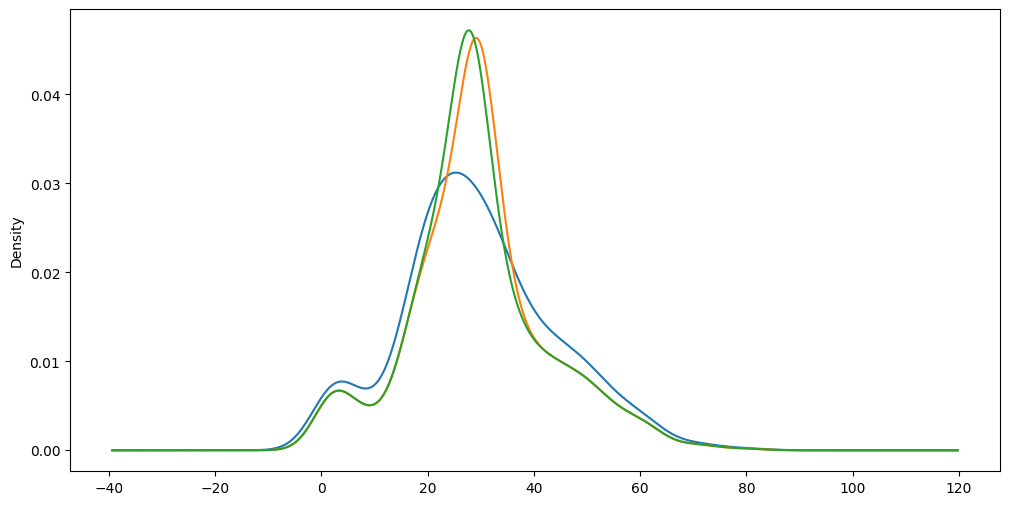

In [94]:
fig,ax=plt.subplots(1,1,figsize=(12,6))

x_train["Age"].plot(kind="kde",ax=ax)
x_train_trf_df["age_mean__Age"].plot(kind="kde",ax=ax)
x_train_trf_df["age_median__Age"].plot(kind="kde",ax=ax)


In [95]:
x_train["Age"].skew()

np.float64(0.3310017370749743)

In [96]:
x_train_trf_df["age_mean__Age"].skew()

np.float64(0.3691029285200458)

In [97]:
x_train_trf_df["age_median__Age"].skew()

np.float64(0.43581171974032523)